In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import StackingClassifier,RandomForestClassifier
from sklearn.feature_selection import  SelectKBest, f_classif,mutual_info_classif, chi2



# Load train_with_clusters.csv
df = pd.read_csv('train_with_clusters.csv')
df.columns = df.columns.str.strip().str.replace(' ', '_')


# Select ClusterID
cluster_id = 6
subgroup_df = df[df['ClusterID'] == cluster_id]

X = subgroup_df.drop(columns=['Bankrupt?', 'Index', 'ClusterID'])
y = subgroup_df['Bankrupt?']

print(f"Number of samples in Cluster {cluster_id}:", len(subgroup_df))

Number of samples in Cluster 6: 334


In [2]:
# Reduce features that are correlated
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X_reduced = X.drop(columns=to_drop)
print(f"Reduced {X.shape[1]-X_reduced.shape[1]} correlated Features.")

Reduced 25 correlated Features.


In [3]:
# Further Feature Extraction

selector = SelectKBest(score_func= f_classif, k=3)
selector.fit(X_reduced, y)
selected_features = X_reduced.columns[selector.get_support()]
X_further_reduced=X_reduced[selected_features]
with open(f"selected_features_cluster{cluster_id}.txt", 'w') as f:
    for feat in selected_features:
        f.write(f"{feat}\n")
print(f"Reduced {X_reduced.shape[1]-X_further_reduced.shape[1]} correlated Features.\n{X_further_reduced.shape[1]} Features left.\n")

Reduced 67 correlated Features.
3 Features left.



/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [68] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.11/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [4]:
# Data Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_further_reduced)
print("train data shape:", X_scaled.shape)

train data shape: (334, 3)


In [5]:
# SMOTE Oversampling
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)
print('Dataset before Oversampling:')
print(y.value_counts())
print('Dataset after Oversampling:')
print(y_resampled.value_counts())

Dataset before Oversampling:
Bankrupt?
0    262
1     72
Name: count, dtype: int64
Dataset after Oversampling:
Bankrupt?
0    262
1    262
Name: count, dtype: int64


In [6]:

# Base Model
base_models = [
    ('RandomForest',RandomForestClassifier(random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('decision_tree', DecisionTreeClassifier(random_state=42))
]

# Meta Model
meta_model = RidgeClassifier()

# Build stacking model with cross-validation inside
stacked_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5  # 5-fold cross-validation
)

# Train the stacking model
stacked_model.fit(X_resampled, y_resampled)

StackingClassifier(cv=5,
                   estimators=[('RandomForest',
                                RandomForestClassifier(random_state=42)),
                               ('knn', KNeighborsClassifier()),
                               ('decision_tree',
                                DecisionTreeClassifier(random_state=42))],
                   final_estimator=RidgeClassifier())

In [7]:
# Predict on train_data
fitted_base_models=[]

for name, model in base_models:
    model.fit(X_scaled, y)
    fitted_base_models.append((name, model))


# Predict base models
tt_total=0
tf_total=0
pred_base={}
for name, model in fitted_base_models:

    y_pred = model.predict(X_scaled)
    pred_base[name]=y_pred
    tt_curr = sum((y == 1) & (y_pred == 1))
    tf_curr = sum((y == 1) & (y_pred == 0))

    acc_curr = tt_curr/(tf_curr + tt_curr)

    tt_total+=tt_curr
    tf_total+=tf_curr

    print(f"Base model {name}: accuracy={acc_curr:.2f} [{tt_curr}({tf_curr})]")


total_acc=tt_total/(tf_total + tt_total)
print(f"Total accuracy of Base Model={total_acc:.2f} [{tt_total}({tf_total})]")



# Predict meta model
y_pred_meta = stacked_model.predict(X_scaled)
tt_meta = sum((y == 1) & (y_pred_meta == 1))
tf_meta = sum((y == 1) & (y_pred_meta == 0))

acc_meta = tt_meta/(tf_meta + tt_meta)
print(f"Meta model: accuracy={acc_meta:.2f} [{tt_meta}({tf_meta})]")



Base model RandomForest: accuracy=1.00 [72(0)]
Base model knn: accuracy=0.57 [41(31)]
Base model decision_tree: accuracy=1.00 [72(0)]
Total accuracy of Base Model=0.86 [185(31)]
Meta model: accuracy=1.00 [72(0)]


In [8]:

# Save the trained scaler and stacking model
joblib.dump(scaler, f'scaler_cluster{cluster_id}.pkl')
joblib.dump(stacked_model, f'stacked_model_cluster{cluster_id}.pkl')

print(f"Scaler and stacking model for Cluster {cluster_id} saved.")

Scaler and stacking model for Cluster 6 saved.


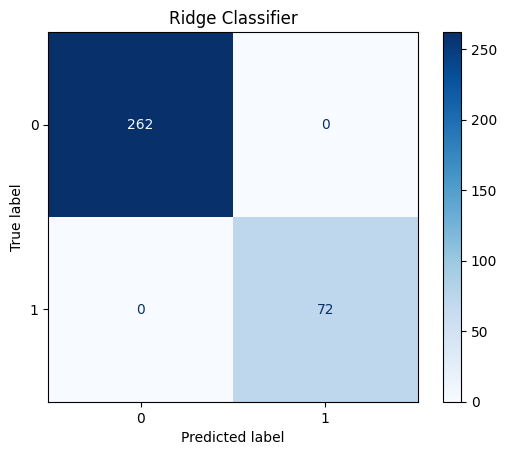


Classification Report:
                  precision    recall  f1-score   support

Not Bankrupt (0)       1.00      1.00      1.00       262
    Bankrupt (1)       1.00      1.00      1.00        72

        accuracy                           1.00       334
       macro avg       1.00      1.00      1.00       334
    weighted avg       1.00      1.00      1.00       334



In [9]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate Confusion Matrix
cm = confusion_matrix(y, y_pred_meta)

# Visualize Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title('Ridge Classifier')
plt.show()

# Print Precision, Recall, F1-Score
print("\nClassification Report:")
print(classification_report(y, y_pred_meta, target_names=["Not Bankrupt (0)", "Bankrupt (1)"]))


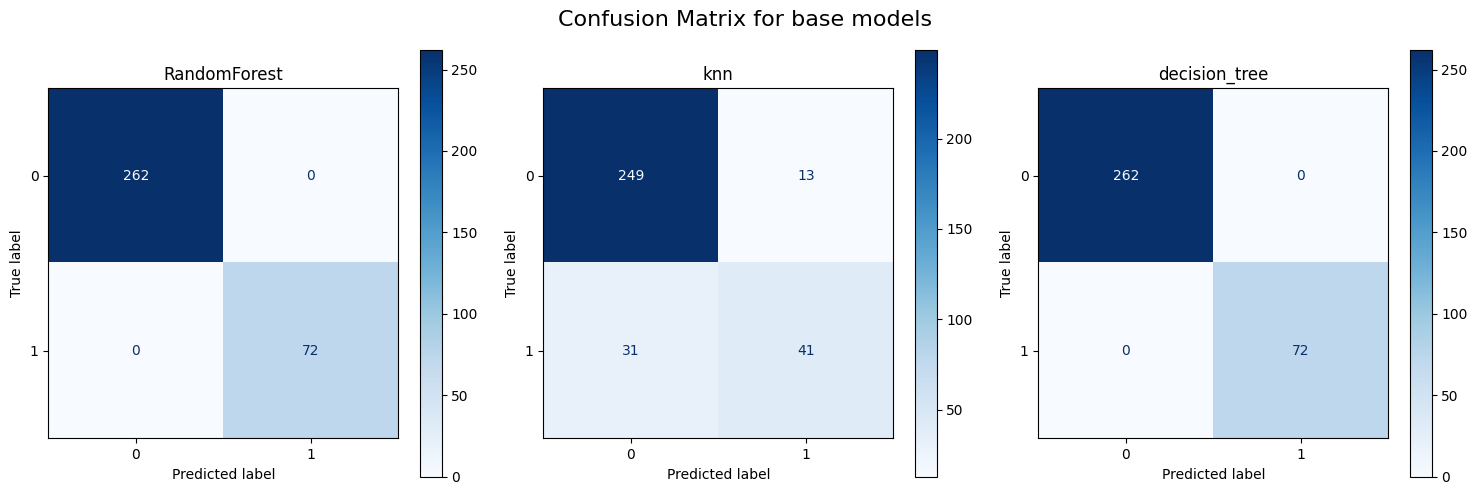

In [10]:
num_cols = 3
num_rows = 1


fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()
names=[item[0] for item in fitted_base_models]
for i in range(len(fitted_base_models)):
    name=names[i]

    cm = confusion_matrix(y, pred_base[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap='Blues',ax=axes[i])


    axes[i].set_title(f'{name}')

fig.suptitle('Confusion Matrix for base models', fontsize=16)
plt.tight_layout()
plt.show()

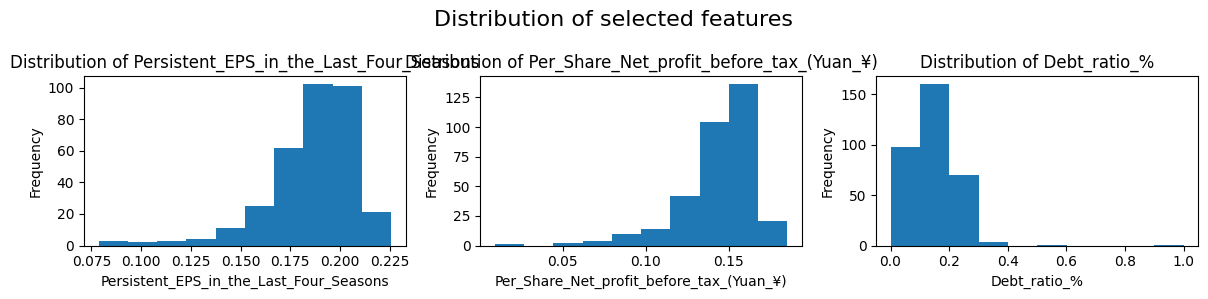

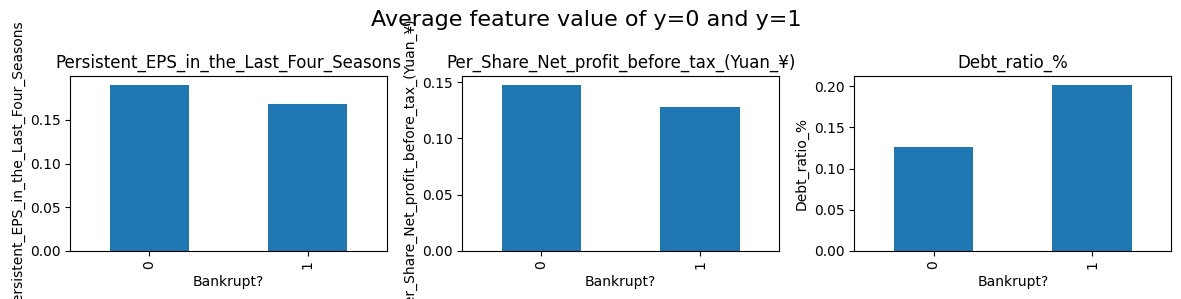

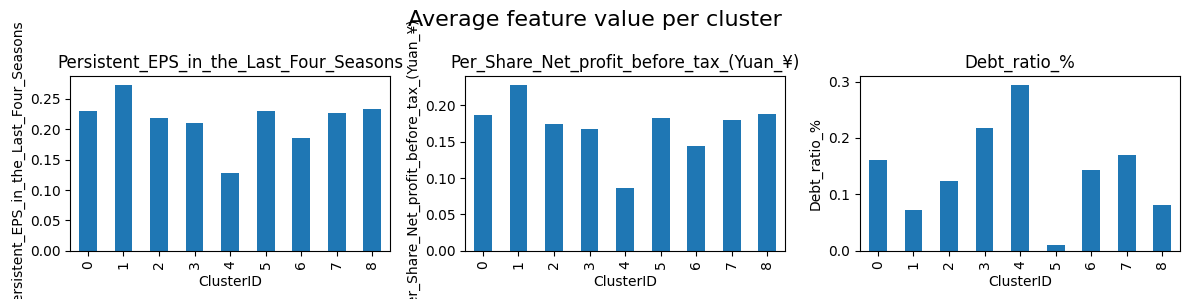

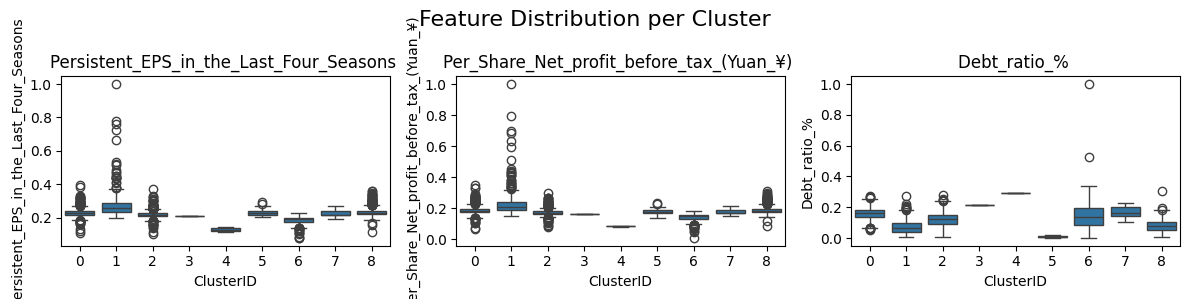

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np



def visualize():

    num_cols = len(selected_features)  # Number of columns in the subplot grid
    num_rows = 1

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))  # Create subplots grid

    if not isinstance(axes, (np.ndarray)):
        axes = np.array([axes])
    axes = axes.flatten()  # Flatten the axes array for easier indexing
    for  i in range(len(selected_features)):
        feature=selected_features[i]
        # Plot histograms
        axes[i].hist(X[feature], bins=10)
        plt.tight_layout()
        axes[i].set_title(f'Distribution of {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Frequency')

    fig.suptitle('Distribution of selected features', fontsize=16)
    plt.tight_layout()

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))  # Create subplots grid

    if not isinstance(axes, (np.ndarray)):
        axes = np.array([axes])
    axes = axes.flatten()  # Flatten the axes array for easier indexing
    for i, feature in enumerate(selected_features):
        feature_mean = subgroup_df.groupby('Bankrupt?')[feature].mean()

        feature_mean.plot(kind='bar', ax=axes[i])
        axes[i].set_title(f'{feature}')
        axes[i].set_xlabel('Bankrupt?')
        axes[i].set_ylabel(feature)
    fig.suptitle('Average feature value of y=0 and y=1', fontsize=16)
    plt.tight_layout()

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
    if not isinstance(axes, (np.ndarray)):
        axes = np.array([axes])
    # axes = axes.flatten()

    for i, feature in enumerate(selected_features):

        mean_feature = df.groupby('ClusterID')[feature].mean()
        mean_feature.plot(kind='bar', ax=axes[i])  # Plot on the corresponding subplot
        axes[i].set_title(f'{feature}')
        axes[i].set_xlabel('ClusterID')
        axes[i].set_ylabel(feature)
    fig.suptitle('Average feature value per cluster', fontsize=16)
    plt.tight_layout()

    # Step 5: Plot boxplots for feature distributions across clusters using subplots
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4 * num_cols, 3 * num_rows))
    if not isinstance(axes, (np.ndarray)):
        axes = np.array([axes])
    axes = axes.flatten()

    for i, feature in enumerate(selected_features):
        sns.boxplot(x='ClusterID', y=feature, data=df, ax=axes[i])
        axes[i].set_title(f'{feature} ')
        axes[i].set_xlabel('ClusterID')
        axes[i].set_ylabel(feature)
    fig.suptitle('Feature Distribution per Cluster', fontsize=16)
    plt.tight_layout()
    plt.show()


visualize()